# numpy_masking_piecewise_and_pipelines.ipynb

1. **Plot and validate f(x)=2(x-1)^2+4**


Max error: 0.0
All close? True


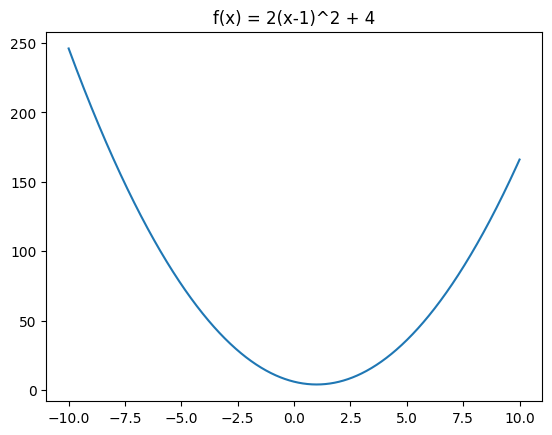

In [1]:
# Plot and validate f(x)=2(x-1)^2+4
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Domain
x = np.linspace(-10, 10, 1000)

# NumPy computation
y_numpy = 2*(x - 1)**2 + 4

# SymPy → numeric
x_sym = sp.symbols("x")
expr = 2*(x_sym - 1)**2 + 4
f_sym = sp.lambdify(x_sym, expr, "numpy")
y_sympy = f_sym(x)

# Validation
error = np.max(np.abs(y_numpy - y_sympy))
print("Max error:", error)
print("All close?", np.allclose(y_numpy, y_sympy))

# Plot (single source of truth)
plt.plot(x, y_numpy)
plt.title("f(x) = 2(x-1)^2 + 4")
plt.show()

2. **How do you code f(x)=\sqrt{x+5} without breaking the domain?**
Focus on valid inputs and output shape.

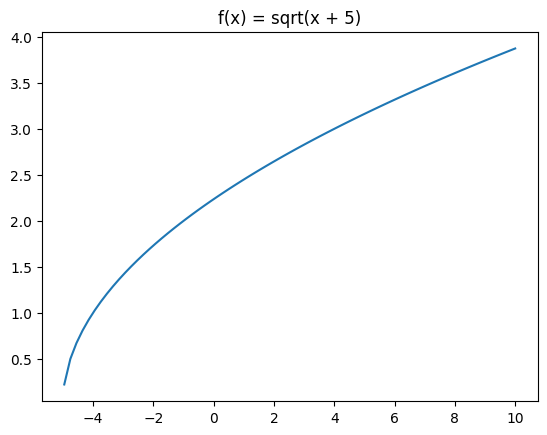

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 🔧 Domain
x = np.linspace(-10, 10, 100)

# 🔧 Mask valid inputs
mask = x >= -5

x_valid = x[mask]
y_valid = np.sqrt(x_valid + 5)

# 🔧 Plot
plt.plot(x_valid, y_valid)
plt.title("f(x) = sqrt(x + 5)")
plt.show()

----

1. **How do you implement a piecewise function on a NumPy array?**
   Example: if (x<0), use (x^2); if (0\le x<2), use (2x+1); otherwise use (\sqrt{x}).
   This forces masking and branching.'''

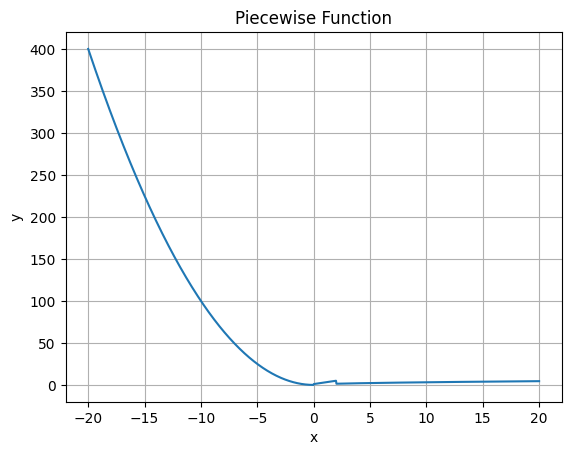

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 🔧 Input range
x = np.linspace(-20, 20, 1000)

# 🔧 Output array (same shape as x)
y = np.zeros_like(x)

# 🔧 Piecewise masks
mask1 = x < 0
mask2 = (x >= 0) & (x < 2)
mask3 = x >= 2

# 🔧 Apply piecewise definitions
y[mask1] = x[mask1]**2          # x^2
y[mask2] = 2*x[mask2] + 1      # 2x + 1
y[mask3] = np.sqrt(x[mask3])   # sqrt(x)

# 🔧 Plot
plt.figure()
plt.plot(x, y)
plt.title("Piecewise Function")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

2. **How do you build a function only on valid inputs and leave invalid inputs untouched?**
   Example: apply (\log(x-1)) only where (x>1), and mark the rest clearly.
   This trains domain filtering.

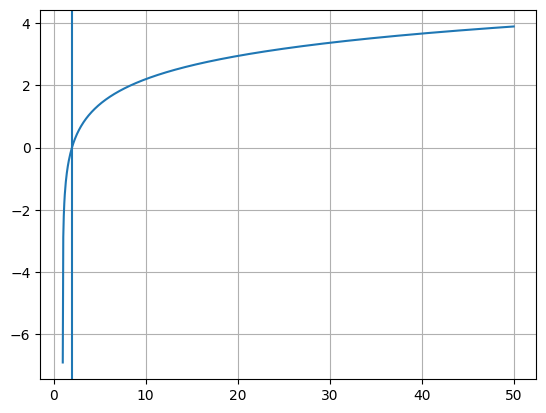

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 50, 1000)

# 🔧 Fill everything as undefined initially
y = np.full_like(x, np.nan)

# 🔧 Valid domain
mask = x > 1

# 🔧 Compute only on valid region
y[mask] = np.log(x[mask] - 1)

# 🔧 Plot
plt.plot(x, y)
plt.axvline(x=2)
plt.grid()
plt.show()

3. **How do you compute a function, then reuse its output in a second rule?**
   Example: (y=f(x)), then if (y>3), square it; otherwise add 5.
   This is real pipeline logic.

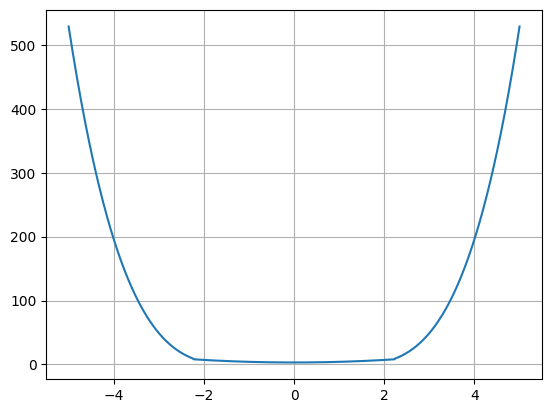

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)

# 🔧 First function
y = x**2 - 2

# 🔧 Second rule
z = np.where(y > 3, y**2, y + 5)

# 🔧 Plot
plt.plot(x, z)

plt.grid()
plt.show()

4. **How do you implement nested transformations in the correct order?**
   Example: first shift, then scale, then apply a nonlinear function, then shift again.
   The challenge is order, not syntax.

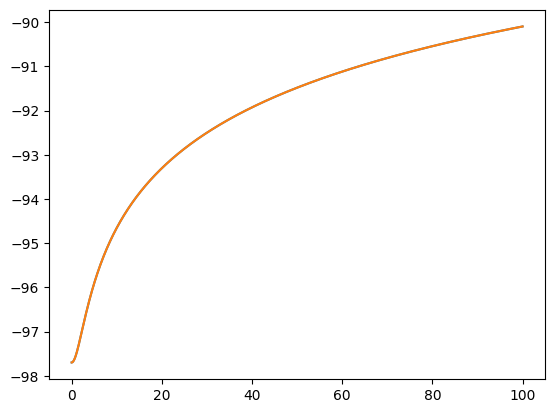

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0,100,1000)
y = np.zeros_like(x)

y1 = x**2

def transform(y1):
    y1 = y1+5
    y1 = y1*2
    y1 = np.log(y1)
    y1 = y1-100
    return y1

new = transform(y1)

plt.plot(x, new)
plt.plot(x, transform(y1))

5.  **How do you implement a clipped or capped function?**
   Example: any value above 10 becomes 10, any value below 0 becomes 0.
   Simple idea, but it trains control logic

-15 : 0
-14 : 0
-13 : 0
-12 : 0
-11 : 0
-10 : 0
-9 : 0
-8 : 0
-7 : 0
-6 : 0
-5 : 0
-4 : 0
-3 : 0
-2 : 0
-1 : 0
0 : 0
1 : 1
2 : 2
3 : 3
4 : 4
5 : 5
6 : 6
7 : 7
8 : 8
9 : 9
10 : 10
11 : 10
12 : 10
13 : 10
14 : 10


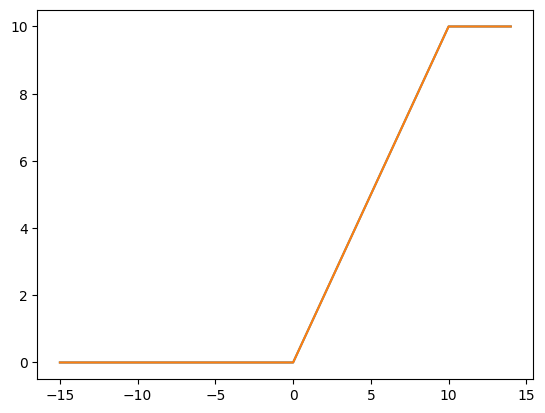

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-15,15)
y = x.copy()

mask1 = x > 10
mask2 = x < 0

y[mask1] = 10
y[mask2] = 0

plt.plot(x,y)

#------------------------------
# or use.
y1 = np.clip(x, 0, 10)

for original, clipped in zip(x, y1):
    print(f"{original} : {clipped}")

plt.plot(x,y1)

10. **How do you build a function that depends on both the value and the sign of the input?**
    Example: if negative, reflect it; if positive, scale it; if zero, handle separately.
    This makes you think in cases.

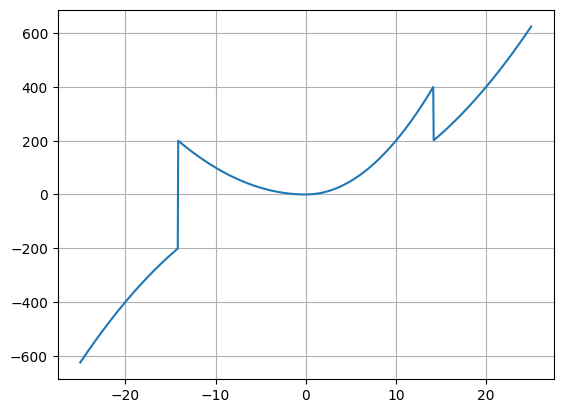

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-25,25,1000)
y = np.zeros_like(x)
y1 = np.square(x)

# checking the sign
sign = np.sign(x)

# double made up conditional filtering
mask1 = (sign == -1) & (y1 > 200)
mask2 = (sign == 1) & (y1 <=200)

y1[mask1] = -1*y1[mask1]
y1[mask2] = 2*y1[mask2]

plt.plot(x,y1)
plt.grid()
plt.show()

----

2. **How do you handle a function with a restricted domain 
    and still keep the original array shape?**
   Example: (f(x)=\sqrt{x-3}).

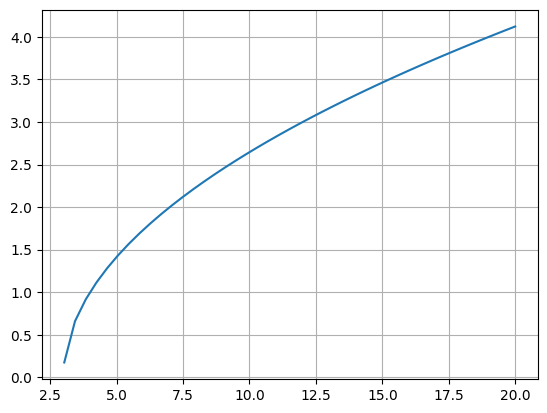

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-20,20,100)

y = np.full_like(x, np.nan)

mask = x >= 3

y[mask] = np.sqrt(x[mask] - 3)

plt.plot(x,y)
plt.grid()
plt.show()

3. **How do you build a clean pipeline where output from one function becomes input to another, but only after validation?**

    Example: compute g(x)=log(x+2), then feed that into h(u)=u
2
+1.

    Some values will fail early. You need to decide what gets passed forward.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-50,50,1000)
y = np.full_like(x, np.nan)

mask = x > -2
y[mask] = np.log(x[mask]+2)

y = y**2 + 1

plt.plot(x,y)